# 1D Masked CNN for DNA Sequence Modeling

This notebook implements a 1D Convolutional Neural Network for masked language modeling on DNA sequences, replacing the BERT architecture while maintaining the same input/output structure for compatibility with existing evaluation pipelines.

## 1. Import Required Libraries and Setup

In [1]:
%load_ext autoreload
%autoreload 2

import os
import wandb
import torch
import random
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import sys

# Add parent directory to path to access modules
sys.path.append('..')

from torch.utils.data import Dataset

from modules.dna_tokenizer import DNATokenizer
from modules.masked_cnn import MaskedCNNConfig, DNACNNForMaskedLM
from helpers.conf_matrix import plot_evaluation_results

from transformers import DataCollatorForLanguageModeling
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback

/home/shishir-sunar/anaconda3/envs/insdel_glm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Initialize Tokenizer and Device Configuration

In [2]:
# Global configuration wandb
os.environ["WANDB_PROJECT"] = "dna-cnn-masked-lm"  # project name
os.environ["WANDB_LOG_MODEL"] = "false"
# os.environ["WANDB_API_KEY"] = api key should be set in terminal

# Initialize wandb login
wandb.login()

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("Using device: ", device)

wandb: Currently logged in as: shishir-sunar9 (shishir-sunar9-technical-university-of-munich) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Using device:  cuda


In [3]:
# Create tokenizer
tokenizer = DNATokenizer(vocab=None, deletion_token=False)

# Test tokenization
seq = "ATCGATCG"
tokens = tokenizer(seq, return_tensors="pt")
print("Test tokenization:")
print(f"Sequence: {seq}")
print(f"Tokens: {tokens}")
print(f"Decoded: {tokenizer.decode(tokens['input_ids'][0], skip_special_tokens=True)}")

Test tokenization:
Sequence: ATCGATCG
Tokens: {'input_ids': tensor([[6, 0, 1, 2, 3, 0, 1, 2, 3, 7, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
         4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
         4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
         4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
         4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
         4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
         4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
         4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
         4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
         4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
         4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
         4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4

## 3. Initialize CNN Model with Configuration

In [4]:
# Load CNN configuration
with open("../config_cnn.json", "r") as f:
    config_dict = json.load(f)

# Synchronize config with tokenizer
config_dict["vocab_size"] = tokenizer.vocab_size
config_dict["pad_token_id"] = tokenizer.pad_token_id
config_dict["mask_token_id"] = tokenizer.mask_token_id
config_dict["sep_token_id"] = tokenizer.sep_token_id
config_dict["cls_token_id"] = tokenizer.cls_token_id

config = MaskedCNNConfig(**config_dict)
model = DNACNNForMaskedLM(config)

print(f"1D CNN Model initialized with:")
print(f" - Vocab size: {config.vocab_size}")
print(f" - Hidden size: {config.hidden_size}")
print(f" - Number of conv layers: {config.num_conv_layers}")
print(f" - Kernel size: {config.kernel_size}")
print(f" - Pad token ID: {config.pad_token_id} (Token: {tokenizer.ids_to_tokens[config.pad_token_id]})")
print(f" - Mask token ID: {config.mask_token_id} (Token: {tokenizer.ids_to_tokens[config.mask_token_id]})")
print(f" - CLS token ID: {config.cls_token_id} (Token: {tokenizer.ids_to_tokens[config.cls_token_id]})")

1D CNN Model initialized with:
 - Vocab size: 8
 - Hidden size: 32
 - Number of conv layers: 8
 - Kernel size: 7
 - Pad token ID: 4 (Token: [PAD])
 - Mask token ID: 5 (Token: [MASK])
 - CLS token ID: 6 (Token: [CLS])


In [5]:
# Count total parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel Parameter Summary:")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {total_params - trainable_params:,}")


Model Parameter Summary:
Total parameters: 58,376
Trainable parameters: 58,376
Non-trainable parameters: 0


## 4. Load and Prepare DNA Dataset

In [6]:
class DNADataset(Dataset):
    def __init__(self, sequences, tokenizer, max_length=32):
        self.sequences = sequences
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        item = self.tokenizer(
            self.sequences[idx],
            padding="max_length",
            max_length=self.max_length,
            truncation=True
        )
        return {k: v.squeeze(0) for k, v in item.items()}

# Load training and validation datasets
train_df = pd.read_parquet("../data/simulated/new_baseline_train.parquet")
val_df = pd.read_parquet("../data/simulated/new_baseline_val.parquet")

train_sequences = train_df["sequences"].tolist()
val_sequences = val_df["sequences"].tolist()

# Create datasets with appropriate max_length
train_dataset = DNADataset(
    sequences=train_sequences, 
    tokenizer=tokenizer, 
    max_length=train_df["sequences"].str.len().max()+2
)
eval_dataset = DNADataset(
    sequences=val_sequences, 
    tokenizer=tokenizer, 
    max_length=val_df["sequences"].str.len().max()+2
)

print(f"Loaded {len(train_dataset)} training samples and {len(eval_dataset)} validation samples.")
print(f"Max sequence length (train): {train_df['sequences'].str.len().max()+2}")
print(f"Max sequence length (val): {val_df['sequences'].str.len().max()+2}")

# Test dataset sample
sample = train_dataset[0]
print(f"Sample input_ids shape: {sample['input_ids'].shape}")
print(f"Sample attention_mask shape: {sample['attention_mask'].shape}")

Loaded 60000 training samples and 20000 validation samples.
Max sequence length (train): 142
Max sequence length (val): 142
Sample input_ids shape: torch.Size([142])
Sample attention_mask shape: torch.Size([142])


## 5. Create Standard Data Collator with Random Masking

In [7]:
# Create standard data collator with 15% masking
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15  # Standard 15% random masking
)

# Test the data collator with a small batch
test_batch = [train_dataset[i] for i in range(2)]
test_output = data_collator(test_batch)
print(f"Test batch input_ids shape: {test_output['input_ids'].shape}")
print(f"Test batch labels shape: {test_output['labels'].shape}")
print(f"Number of masked tokens in test batch: {(test_output['input_ids'] == tokenizer.mask_token_id).sum().item()}")

Test batch input_ids shape: torch.Size([2, 142])
Test batch labels shape: torch.Size([2, 142])
Number of masked tokens in test batch: 34


## 6. Configure Training Arguments and Trainer

In [8]:
# CNN Training Strategy:
# 1. Learning Rate: 1e-4 for CNN (typically need lower LR than BERT)
# 2. Add Warmup: 10% of total steps
# 3. Add Weight Decay: 0.01 for regularization
# 4. Label Smoothing: 0.0 (can experiment with this)
# 5. Gradient Clipping: 1.5

# Initialize wandb for this experiment
wandb.init(project="dna-cnn-masked-lm")

# Training hyperparameters
num_train_epochs = 50
batch_size = 64
total_steps = (len(train_dataset) // batch_size) * num_train_epochs
warmup_steps = int(0.1 * total_steps)

# Update config with label smoothing
config.label_smoothing = 0.0

print(f"Training Configuration:")
print(f" - Epochs: {num_train_epochs}")
print(f" - Batch size: {batch_size}")
print(f" - Total steps: {total_steps}")
print(f" - Warmup steps: {warmup_steps}")

training_args = TrainingArguments(
    output_dir="../checkpoints/simulated_model_cnn_v2",
    num_train_epochs=num_train_epochs,  
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,  
    learning_rate=1e-4,          # CNN typically needs higher LR than BERT
    weight_decay=0.01,           # Add weight decay
    warmup_steps=warmup_steps,   # Add warmup
    max_grad_norm=1.5,           # Gradient clipping
    report_to="wandb",
    run_name="simulated_model_cnn_v2",
    dataloader_pin_memory=False,  # Sometimes helps with CNN training
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5, early_stopping_threshold=0.01)]
)

print("Trainer initialized successfully!")

Training Configuration:
 - Epochs: 50
 - Batch size: 64
 - Total steps: 46850
 - Warmup steps: 4685
Trainer initialized successfully!
Trainer initialized successfully!


## 7. Train the Model

In [9]:
# Start training
print("Starting CNN training...")
print("This may take a while depending on your hardware...")

# Start fresh training (not from checkpoint)
trainer.train(resume_from_checkpoint=False)

print("Training completed!")
wandb.finish()

Starting CNN training...
This may take a while depending on your hardware...


Epoch,Training Loss,Validation Loss
1,1.594800,1.585495
2,1.468800,1.465236
3,1.387800,1.379001
4,1.316300,1.307068
5,1.291600,1.275407
6,1.270300,1.266408
7,1.271900,1.263384
8,1.282600,1.263537
9,1.275200,1.262714
10,1.276700,1.262338


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Training completed!


eval/loss,█▅▄▂▁▁▁▁▁▁
eval/runtime,▂▁▁▆▁▁█▂▂▂
eval/samples_per_second,▆▇▇▂██▁▆▇▆
eval/steps_per_second,▆▇▇▂██▁▆▇▆
train/epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇█████
train/global_step,▁▂▂▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇█████
train/grad_norm,███▇▆▅▂▃▂▂▂▂▁▂▁▂▂▂▂▂▃▂▂▂▂▂▁▁▁▁▁▂▂▂▁▁▂▁▁▁
train/learning_rate,▁▁▃▃▃▃▄▄▅▆▆▇▇█████████████████▇▇▇▇▇▇▇▇▇▇
train/loss,█▇▇▆▅▅▅▄▄▄▃▃▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/loss,1.26234
eval/runtime,4.0332


## 8. Plot Training and Validation Loss Curves

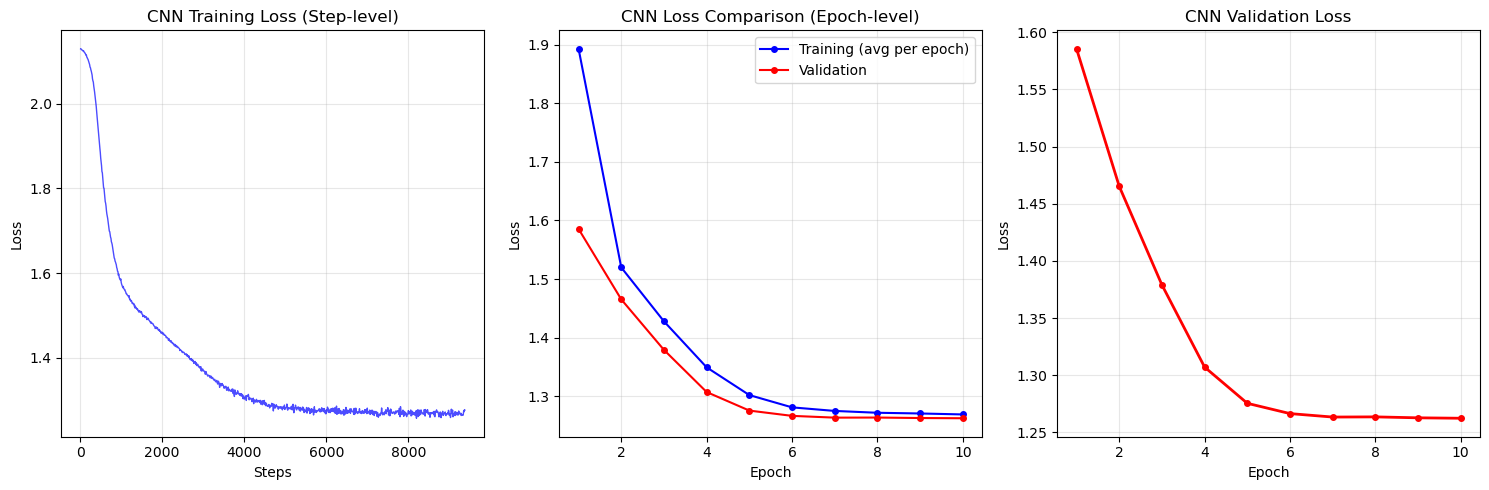

Final training loss: 1.2767
Final validation loss: 1.2623
Best validation loss: 1.2623


In [10]:
# Plot loss curves
logs = trainer.state.log_history
train_logs = [x for x in logs if 'loss' in x and 'eval_loss' not in x]
eval_logs = [x for x in logs if 'eval_loss' in x]

# Get step-level training loss
train_steps = [x['step'] for x in train_logs]
train_losses = [x['loss'] for x in train_logs]

# Get epoch-level validation loss
eval_epochs = [x['epoch'] for x in eval_logs]
eval_losses = [x['eval_loss'] for x in eval_logs]

# Calculate epoch-averaged training loss
epochs = list(range(1, int(max(eval_epochs)) + 1))
train_loss_per_epoch = []

batch_size = training_args.per_device_train_batch_size
steps_per_epoch = len(train_dataset) // (batch_size * getattr(training_args, 'gradient_accumulation_steps', 1))

for epoch in epochs:
    epoch_start = (epoch - 1) * steps_per_epoch
    epoch_end = epoch * steps_per_epoch
    
    epoch_losses = [loss for step, loss in zip(train_steps, train_losses) 
                    if epoch_start < step <= epoch_end]
    
    if epoch_losses:
        train_loss_per_epoch.append(np.mean(epoch_losses))
    else:
        train_loss_per_epoch.append(None)

plt.figure(figsize=(15, 5))

# Plot 1: Step-level training loss
plt.subplot(1, 3, 1)
plt.plot(train_steps, train_losses, 'b-', alpha=0.7, linewidth=1)
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('CNN Training Loss (Step-level)')
plt.grid(True, alpha=0.3)

# Plot 2: Epoch-level comparison
plt.subplot(1, 3, 2)
plt.plot(epochs, train_loss_per_epoch, 'bo-', label='Training (avg per epoch)', markersize=4)
plt.plot(eval_epochs, eval_losses, 'ro-', label='Validation', markersize=4)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Loss Comparison (Epoch-level)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Validation loss only
plt.subplot(1, 3, 3)
plt.plot(eval_epochs, eval_losses, 'ro-', linewidth=2, markersize=4)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Validation Loss')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final training loss: {train_losses[-1]:.4f}")
print(f"Final validation loss: {eval_losses[-1]:.4f}")
print(f"Best validation loss: {min(eval_losses):.4f}")

## 9. Save the Trained Model

In [11]:
# Save the trained model
project_root = Path.cwd().parent
save_directory = project_root / "model" / "CNN_baseline_100k_1e-4"

# Create directory if it doesn't exist
save_directory.mkdir(parents=True, exist_ok=True)

# Save using trainer (this saves both model and config)
trainer.save_model(str(save_directory))

# Also save the config separately for easy access
with open(save_directory / "config_cnn.json", "w") as f:
    json.dump(config.to_dict(), f, indent=2)

print(f"Model saved to: {save_directory}")
print(f"Saved files: {list(save_directory.glob('*'))}")

Model saved to: /home/shishir-sunar/InsDelGLM/model/CNN_baseline_100k_1e-4
Saved files: [PosixPath('/home/shishir-sunar/InsDelGLM/model/CNN_baseline_100k_1e-4/special_tokens_map.json'), PosixPath('/home/shishir-sunar/InsDelGLM/model/CNN_baseline_100k_1e-4/vocab.txt'), PosixPath('/home/shishir-sunar/InsDelGLM/model/CNN_baseline_100k_1e-4/training_args.bin'), PosixPath('/home/shishir-sunar/InsDelGLM/model/CNN_baseline_100k_1e-4/model.safetensors'), PosixPath('/home/shishir-sunar/InsDelGLM/model/CNN_baseline_100k_1e-4/config_cnn.json'), PosixPath('/home/shishir-sunar/InsDelGLM/model/CNN_baseline_100k_1e-4/config.json'), PosixPath('/home/shishir-sunar/InsDelGLM/model/CNN_baseline_100k_1e-4/tokenizer_config.json')]


## 10. Load Model and Evaluate on Validation Set

In [ ]:
# Load the saved model for evaluation
project_root = Path.cwd().parent
model_directory = project_root / "model" / "CNN_baseline_100k_1e-4"

from safetensors.torch import load_file

# Update config before loading to ensure alignment
with open("../config_cnn.json", "r") as f:
    config_dict = json.load(f)
config_dict["vocab_size"] = tokenizer.vocab_size
config_dict["pad_token_id"] = tokenizer.pad_token_id
config_dict["mask_token_id"] = tokenizer.mask_token_id
config_dict["sep_token_id"] = tokenizer.sep_token_id
config_dict["cls_token_id"] = tokenizer.cls_token_id
eval_config = MaskedCNNConfig(**config_dict)

# Load the trained model
loaded_model = DNACNNForMaskedLM(eval_config)
state_dict = load_file(model_directory / "model.safetensors")
loaded_model.load_state_dict(state_dict)
loaded_model.to(device)
loaded_model.eval()

print(f"Loaded CNN model from: {model_directory}")
print(f"Model device: {next(loaded_model.parameters()).device}")

# Create evaluation arguments
eval_args = TrainingArguments(
    output_dir="../checkpoints/temp_eval_cnn",
    per_device_eval_batch_size=16,
    do_train=False,
    do_eval=True,
    dataloader_pin_memory=False,
)

eval_trainer = Trainer(
    model=loaded_model,
    args=eval_args,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
)

print("Running prediction on validation set...")
output = eval_trainer.predict(eval_dataset)

logits = output.predictions
labels = output.label_ids
pred_ids_flat = np.argmax(logits, axis=-1).flatten()
labels_flat = labels.flatten()

# EVALUATION FILTERING LOGIC:
# 1. Labels != -100: Only look at masked positions
# 2. Labels not in special_ids: Only look at positions that were originally DNA bases
special_ids = tokenizer.all_special_ids
mask = (labels_flat != -100)
for sid in special_ids:
    mask &= (labels_flat != sid)

true_ids_filtered = labels_flat[mask]
pred_ids_filtered = pred_ids_flat[mask]

print(f"Total DNA tokens for evaluation: {len(true_ids_filtered)}")
print(f"Evaluation accuracy: {(true_ids_filtered == pred_ids_filtered).mean():.2%}")

# Generate confusion matrix and evaluation plots
plot_evaluation_results(
    true_ids_filtered,
    pred_ids_filtered,
    tokenizer,
    dataset_name="CNN Validation (Filtered for DNA positions)"
)

## 11. Analyze Prediction Bias and Distribution

In [ ]:
# Additional analysis for prediction bias and token distribution
from collections import Counter

def analyze_bias(true_ids, pred_ids, tokenizer):
    """Analyze prediction bias and token-level performance."""
    true_counts = Counter(true_ids)
    pred_counts = Counter(pred_ids)
    
    print("\n" + "="*60)
    print("CNN PREDICTION DISTRIBUTION ANALYSIS")
    print("="*60)
    print(f"{'Token':<10} | {'True Count':<12} | {'Pred Count':<12} | {'Recall':<8} | {'Precision':<10}")
    print("-" * 70)
    
    total_correct = 0
    total_predictions = len(pred_ids)
    
    for token_id in sorted(true_counts.keys()):
        token_name = tokenizer.ids_to_tokens[token_id]
        t_count = true_counts[token_id]
        p_count = pred_counts.get(token_id, 0)
        
        # Calculate recall: how many of the true instances were predicted correctly
        correct = np.sum((true_ids == token_id) & (pred_ids == token_id))
        recall = correct / t_count if t_count > 0 else 0
        
        # Calculate precision: of all predictions for this token, how many were correct
        precision = correct / p_count if p_count > 0 else 0
        
        total_correct += correct
        
        print(f"{token_name:<10} | {t_count:<12} | {p_count:<12} | {recall:.2%}   | {precision:.2%}")
    
    overall_accuracy = total_correct / len(true_ids)
    print("-" * 70)
    print(f"Overall Accuracy: {overall_accuracy:.2%}")
    
    # Calculate prediction entropy to detect bias
    pred_probs = np.array(list(pred_counts.values())) / total_predictions
    entropy = -np.sum(pred_probs * np.log2(pred_probs + 1e-10))
    max_entropy = np.log2(len(pred_counts))
    print(f"Prediction Entropy: {entropy:.3f} (max: {max_entropy:.3f})")
    print(f"Entropy Ratio: {entropy/max_entropy:.2%} (higher = less biased)")
    
    return overall_accuracy, entropy

# Perform bias analysis
accuracy, entropy = analyze_bias(true_ids_filtered, pred_ids_filtered, tokenizer)

# Additional visualizations
plt.figure(figsize=(15, 5))

# Plot 1: True vs Predicted distributions
true_counts = Counter(true_ids_filtered)
pred_counts = Counter(pred_ids_filtered)

tokens = [tokenizer.ids_to_tokens[tid] for tid in sorted(true_counts.keys())]
true_vals = [true_counts[tid] for tid in sorted(true_counts.keys())]
pred_vals = [pred_counts.get(tid, 0) for tid in sorted(true_counts.keys())]

plt.subplot(1, 3, 1)
x = np.arange(len(tokens))
width = 0.35
plt.bar(x - width/2, true_vals, width, label='True', alpha=0.7)
plt.bar(x + width/2, pred_vals, width, label='Predicted', alpha=0.7)
plt.xlabel('DNA Bases')
plt.ylabel('Count')
plt.title('True vs Predicted Token Distribution')
plt.xticks(x, tokens)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Per-token accuracy
accuracies = []
for token_id in sorted(true_counts.keys()):
    correct = np.sum((true_ids_filtered == token_id) & (pred_ids_filtered == token_id))
    total = true_counts[token_id]
    accuracies.append(correct / total)

plt.subplot(1, 3, 2)
plt.bar(tokens, accuracies, alpha=0.7, color='green')
plt.xlabel('DNA Bases')
plt.ylabel('Recall')
plt.title('Per-Token Recall (CNN)')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)

# Plot 3: Confusion matrix visualization
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(true_ids_filtered, pred_ids_filtered, labels=sorted(true_counts.keys()))
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.subplot(1, 3, 3)
im = plt.imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Normalized Confusion Matrix (CNN)')
plt.colorbar(im)
tick_marks = np.arange(len(tokens))
plt.xticks(tick_marks, tokens)
plt.yticks(tick_marks, tokens)
plt.xlabel('Predicted')
plt.ylabel('True')

plt.tight_layout()
plt.show()

print(f"\nCNN Model Performance Summary:")
print(f"   Overall Accuracy: {accuracy:.2%}")
print(f"   Prediction Entropy: {entropy:.3f}")
print(f"   Model appears {'less' if entropy > 1.5 else 'more'} biased in predictions")

## Summary

This notebook implements a 1D Convolutional Neural Network for DNA sequence masked language modeling. The key features include:

1. **1D CNN Architecture**: Replace BERT attention mechanism with convolutional layers
2. **Residual Connections**: Every 2 layers to help gradient flow
3. **Standard Random Masking**: 15% random masking for training
4. **Compatible Interface**: Same input/output structure as BERT for seamless evaluation
5. **Comprehensive Evaluation**: Confusion matrices, per-token analysis, and bias detection

The CNN model offers several advantages:
- **Computational Efficiency**: Faster training than transformers
- **Local Pattern Recognition**: Excellent for motif detection in DNA sequences
- **Parameter Efficiency**: Fewer parameters than equivalent BERT models
- **Sequence Translation Invariance**: Natural for sequence data

Use this model for further downstream tasks with the same evaluation pipeline as the BERT baseline.